In [1]:
import pandas as pd
from sklearn.preprocessing import PowerTransformer

df = pd.read_csv("Salary_Data.csv")

df = df.dropna()

df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

def clean_education(x):
    x = str(x).strip().lower()
    if "phd" in x:
        return "PhD"
    elif "master" in x:
        return "Master's"
    elif "bachelor" in x:
        return "Bachelor's"
    elif "high school" in x:
        return "High School"
    else:
        return x

df['Education Level'] = df['Education Level'].apply(clean_education)

df = pd.get_dummies(df, columns=['Education Level'])

df = df.rename(columns={
    "Education Level_Bachelor's": "bachelor",
    "Education Level_High School": "high_school",
    "Education Level_Master's": "masters",
    "Education Level_PhD": "phd"
})

df[['bachelor','high_school','masters','phd']] = df[['bachelor','high_school','masters','phd']].astype(int)

pt = PowerTransformer(method='yeo-johnson')
df['Age'] = pt.fit_transform(df[['Age']])

In [5]:
df

,Age,Gender,Job Title,Years of Experience,Salary,bachelor,high_school,masters,phd
0,-0.005862,0.0,Software Engineer,5.0,90000.0,1,0,0,0
1,-0.717950,1.0,Data Analyst,3.0,65000.0,0,0,1,0
2,1.396679,0.0,Senior Manager,15.0,150000.0,0,0,0,1
3,0.540283,1.0,Sales Associate,7.0,60000.0,1,0,0,0
4,1.846876,0.0,Director,20.0,200000.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
6699,1.670727,1.0,Director of Marketing,20.0,200000.0,0,0,0,1
6700,-0.005862,0.0,Sales Associate,3.0,50000.0,0,1,0,0
6701,-0.336900,1.0,Financial Manager,4.0,55000.0,1,0,0,0
6702,1.469958,0.0,Marketing Manager,14.0,140000.0,0,0,1,0


In [4]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Age'] >= lower) & (df['Age'] <= upper)]

In [21]:
df['Job Title'].value_counts()

Job Title
manager                              1379
software                             1378
data_science                         1169
project_engineer                      324
Full Stack Engineer                   308
                                     ... 
Senior Quality Assurance Analyst        1
Senior Human Resources Specialist       1
Director of Human Capital               1
Junior Financial Advisor                1
Social Media Man                        1
Name: count, Length: 121, dtype: int64

In [8]:
df['Job Title'] = df['Job Title'].apply(lambda x: 'software' if 'software' in str(x).lower() else x)

In [10]:
df['Job Title'] = df['Job Title'].apply(lambda x: 'manager' if 'manager' in str(x).lower() else x)

In [13]:
df['Job Title'] = df['Job Title'].apply(lambda x: 'data_science' if 'data' in str(x).lower() else x)

In [15]:
df['Job Title'] = df['Job Title'].apply(
    lambda x: 'data_science' if any(k in str(x).lower() for k in ['data','research','scientist']) else x
)

In [20]:
df['Job Title'] = df['Job Title'].apply(lambda x: 'project_engineer' if 'project' in str(x).lower() else x)

In [23]:
df['Job Title'].str.lower().str.contains('engineer').sum()

np.int64(719)

In [55]:
df['Job Title'].value_counts().head(10)

Job Title
manager              1379
software             1378
data_science         1169
Developer Roles       646
engineer              636
Marketing             571
sales_job             394
HR                    264
Receptionist           57
Financial Analyst      39
Name: count, dtype: int64

In [27]:
df['Job Title'] = df['Job Title'].apply(
    lambda x: 'Marketing' if any(k in str(x).lower() for k in ['market','marketing','product']) else x
)

In [53]:
df['Job Title'].value_counts()

Job Title
manager                             1379
software                            1378
data_science                        1169
Developer Roles                      646
engineer                             636
                                    ... 
Senior Account Executive               1
Senior Quality Assurance Analyst       1
Junior Advertising Coordinator         1
Junior Operations Coordinator          1
Junior Financial Advisor               1
Name: count, Length: 75, dtype: int64

In [30]:
df['Job Title'] = df['Job Title'].apply(lambda x: 'Developer Roles' if 'developer' in str(x).lower() else x)

In [33]:
df['Job Title'] = df['Job Title'].apply(lambda x: 'Media Company' if 'media' in str(x).lower() else x)

In [37]:
df['Job Title'] = df['Job Title'].apply(
    lambda x: 'senior_engineer' if ('senior' in str(x).lower() and 'engineer' in str(x).lower())
    else ('engineer' if 'engineer' in str(x).lower() else x)
)

In [40]:
df['Job Title'] = df['Job Title'].apply(
    lambda x: 'sales_job' if any(k in str(x).lower() for k in ['sale','sales']) else x
)

In [44]:
df['Job Title'] = df['Job Title'].apply(lambda x: 'HR' if 'hr' in str(x).lower() else x)

In [47]:
df['Job Title'] = df['Job Title'].apply(
    lambda x: 'HR' if any(k in str(x).lower() for k in ['hr','human']) else x
)

In [52]:
df['Job Title'] = df['Job Title'].apply(
    lambda x: 'finance' if any(k in str(x).lower() for k in ['finance','money']) else x
)

In [56]:
top8 = df['Job Title'].value_counts().head(8).index

df['Job'] = df['Job Title'].apply(lambda x: x if x in top8 else 'others')

In [57]:
df

,Age,Gender,Job Title,Years of Experience,Salary,bachelor,high_school,masters,phd,Job
0,-0.005862,0.0,software,5.0,90000.0,1,0,0,0,software
1,-0.717950,1.0,data_science,3.0,65000.0,0,0,1,0,data_science
2,1.396679,0.0,manager,15.0,150000.0,0,0,0,1,manager
3,0.540283,1.0,sales_job,7.0,60000.0,1,0,0,0,sales_job
4,1.846876,0.0,Director,20.0,200000.0,0,0,1,0,others
...,...,...,...,...,...,...,...,...,...,...
6699,1.670727,1.0,Marketing,20.0,200000.0,0,0,0,1,Marketing
6700,-0.005862,0.0,sales_job,3.0,50000.0,0,1,0,0,sales_job
6701,-0.336900,1.0,manager,4.0,55000.0,1,0,0,0,manager
6702,1.469958,0.0,manager,14.0,140000.0,0,0,1,0,manager


In [63]:
df['Job'].value_counts()

Job
Manager              1379
Software Engineer    1378
Data Science         1169
Developer Roles       646
Engineer              636
Marketing             571
Sales                 394
HR                    264
Others                261
Name: count, dtype: int64

In [62]:
df['Job'] = df['Job'].replace({
    'manager': 'Manager',
    'software': 'Software Engineer',
    'data_science': 'Data Science',
    'engineer': 'Engineer',
    'sales_job': 'Sales',
    'others': 'Others',
    'Developer Roles': 'Developer Roles',
})

In [70]:
df

,Age,Gender,Job Title,Years of Experience,Salary,bachelor,high_school,masters,phd,Job_Data Science,Job_Engineer,Job_HR,Job_Manager,Job_Marketing,Job_Others,Job_Sales
0,-0.005862,0.0,Software Engineer,5.0,90000.0,1,0,0,0,False,True,False,False,False,False,False
1,-0.717950,1.0,Data Science,3.0,65000.0,0,0,1,0,True,False,False,False,False,False,False
2,1.396679,0.0,Manager,15.0,150000.0,0,0,0,1,False,False,False,True,False,False,False
3,0.540283,1.0,Sales,7.0,60000.0,1,0,0,0,False,False,False,False,False,False,True
4,1.846876,0.0,Director,20.0,200000.0,0,0,1,0,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6699,1.670727,1.0,Marketing,20.0,200000.0,0,0,0,1,False,False,False,False,True,False,False
6700,-0.005862,0.0,Sales,3.0,50000.0,0,1,0,0,False,False,False,False,False,False,True
6701,-0.336900,1.0,Manager,4.0,55000.0,1,0,0,0,False,False,False,True,False,False,False
6702,1.469958,0.0,Manager,14.0,140000.0,0,0,1,0,False,False,False,True,False,False,False


In [65]:
df['Job'] = df['Job'].replace({
    'Developer Roles': 'Engineer',
    'Software Engineer': 'Engineer'
})

In [ ]:
# df = pd.get_dummies(df, columns=['Job'])

# df = df.astype({col: int for col in df.columns if 'Job Title_' in col})

KeyError: "None of [Index(['Job'], dtype='object')] are in the [columns]"

In [71]:
df = df.astype({col: int for col in df.columns if col.startswith('Job_')})

In [72]:
df

,Age,Gender,Job Title,Years of Experience,Salary,bachelor,high_school,masters,phd,Job_Data Science,Job_Engineer,Job_HR,Job_Manager,Job_Marketing,Job_Others,Job_Sales
0,-0.005862,0.0,Software Engineer,5.0,90000.0,1,0,0,0,0,1,0,0,0,0,0
1,-0.717950,1.0,Data Science,3.0,65000.0,0,0,1,0,1,0,0,0,0,0,0
2,1.396679,0.0,Manager,15.0,150000.0,0,0,0,1,0,0,0,1,0,0,0
3,0.540283,1.0,Sales,7.0,60000.0,1,0,0,0,0,0,0,0,0,0,1
4,1.846876,0.0,Director,20.0,200000.0,0,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6699,1.670727,1.0,Marketing,20.0,200000.0,0,0,0,1,0,0,0,0,1,0,0
6700,-0.005862,0.0,Sales,3.0,50000.0,0,1,0,0,0,0,0,0,0,0,1
6701,-0.336900,1.0,Manager,4.0,55000.0,1,0,0,0,0,0,0,1,0,0,0
6702,1.469958,0.0,Manager,14.0,140000.0,0,0,1,0,0,0,0,1,0,0,0


In [75]:
import seaborn as sns
corr = df.corr(numeric_only=True)
print(corr)

                          Age    Gender  Years of Experience    Salary  \
Age                  1.000000 -0.110697             0.914518  0.746977   
Gender              -0.110697  1.000000            -0.098809 -0.127276   
Years of Experience  0.914518 -0.098809             1.000000  0.808968   
Salary               0.746977 -0.127276             0.808968  1.000000   
bachelor            -0.388619 -0.098961            -0.400213 -0.347662   
high_school         -0.294492  0.066315            -0.273040 -0.398776   
masters              0.177170  0.154673             0.158650  0.173645   
phd                  0.465211 -0.090238             0.486796  0.483193   
Job_Data Science     0.040240 -0.043502             0.101112  0.302224   
Job_Engineer         0.049640 -0.105605             0.069225  0.090502   
Job_HR              -0.019199  0.067916            -0.066364 -0.159828   
Job_Manager          0.107462  0.074586             0.072067  0.032673   
Job_Marketing       -0.046777  0.05766

In [ ]:
df.corr(numeric_only=True)['Salary'].sort_values(ascending=False)

Salary                 1.000000
Years of Experience    0.808968
Age                    0.746977
education_encoded      0.545589
IT                     0.321311
Job_Data Science       0.302224
Job_Engineer           0.090502
Job_Manager            0.032673
Job_Marketing         -0.123374
Gender                -0.127276
Sales                 -0.136988
Job_HR                -0.159828
Job_Others            -0.170574
Others                -0.266423
Job_Sales             -0.313001
Name: Salary, dtype: float64

In [77]:
df['education_encoded'] = df.apply(
    lambda x: 0 if (x['bachelor']==1 or x['high_school']==1) else 1,
    axis=1
)

In [78]:
df

,Age,Gender,Job Title,Years of Experience,Salary,bachelor,high_school,masters,phd,Job_Data Science,Job_Engineer,Job_HR,Job_Manager,Job_Marketing,Job_Others,Job_Sales,education_encoded
0,-0.005862,0.0,Software Engineer,5.0,90000.0,1,0,0,0,0,1,0,0,0,0,0,0
1,-0.717950,1.0,Data Science,3.0,65000.0,0,0,1,0,1,0,0,0,0,0,0,1
2,1.396679,0.0,Manager,15.0,150000.0,0,0,0,1,0,0,0,1,0,0,0,1
3,0.540283,1.0,Sales,7.0,60000.0,1,0,0,0,0,0,0,0,0,0,1,0
4,1.846876,0.0,Director,20.0,200000.0,0,0,1,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6699,1.670727,1.0,Marketing,20.0,200000.0,0,0,0,1,0,0,0,0,1,0,0,1
6700,-0.005862,0.0,Sales,3.0,50000.0,0,1,0,0,0,0,0,0,0,0,1,0
6701,-0.336900,1.0,Manager,4.0,55000.0,1,0,0,0,0,0,0,1,0,0,0,0
6702,1.469958,0.0,Manager,14.0,140000.0,0,0,1,0,0,0,0,1,0,0,0,1


In [80]:
df = df.drop(columns=['bachelor','high_school','masters','phd'])

In [81]:
df

,Age,Gender,Job Title,Years of Experience,Salary,Job_Data Science,Job_Engineer,Job_HR,Job_Manager,Job_Marketing,Job_Others,Job_Sales,education_encoded
0,-0.005862,0.0,Software Engineer,5.0,90000.0,0,1,0,0,0,0,0,0
1,-0.717950,1.0,Data Science,3.0,65000.0,1,0,0,0,0,0,0,1
2,1.396679,0.0,Manager,15.0,150000.0,0,0,0,1,0,0,0,1
3,0.540283,1.0,Sales,7.0,60000.0,0,0,0,0,0,0,1,0
4,1.846876,0.0,Director,20.0,200000.0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6699,1.670727,1.0,Marketing,20.0,200000.0,0,0,0,0,1,0,0,1
6700,-0.005862,0.0,Sales,3.0,50000.0,0,0,0,0,0,0,1,0
6701,-0.336900,1.0,Manager,4.0,55000.0,0,0,0,1,0,0,0,0
6702,1.469958,0.0,Manager,14.0,140000.0,0,0,0,1,0,0,0,1


In [84]:
df['IT'] = df[['Job_Data Science','Job_Engineer']].sum(axis=1)
df['Sales'] = df[['Job_Manager','Job_Sales']].sum(axis=1)

job_cols = [col for col in df.columns if col.startswith('Job_')]

df['Others'] = df[job_cols].sum(axis=1) - df['IT'] - df['Sales']

df[['IT','Sales','Others']] = df[['IT','Sales','Others']].clip(upper=1)

df = df.drop(columns=job_cols)

In [85]:
df

,Age,Gender,Job Title,Years of Experience,Salary,education_encoded,IT,Sales,Others
0,-0.005862,0.0,Software Engineer,5.0,90000.0,0,1,0,0
1,-0.717950,1.0,Data Science,3.0,65000.0,1,1,0,0
2,1.396679,0.0,Manager,15.0,150000.0,1,0,1,0
3,0.540283,1.0,Sales,7.0,60000.0,0,0,1,0
4,1.846876,0.0,Director,20.0,200000.0,1,0,0,1
...,...,...,...,...,...,...,...,...,...
6699,1.670727,1.0,Marketing,20.0,200000.0,1,0,0,1
6700,-0.005862,0.0,Sales,3.0,50000.0,0,0,1,0
6701,-0.336900,1.0,Manager,4.0,55000.0,0,0,1,0
6702,1.469958,0.0,Manager,14.0,140000.0,1,0,1,0


In [92]:
df['IT'].value_counts()

IT
1    3829
0    2869
Name: count, dtype: int64

In [91]:
df

,Age,Gender,Job Title,Years of Experience,Salary,education_encoded,IT,Sales,Others
0,-0.005862,0.0,Software Engineer,5.0,90000.0,0,1,0,0
1,-0.717950,1.0,Data Science,3.0,65000.0,1,1,0,0
2,1.396679,0.0,Manager,15.0,150000.0,1,0,1,0
3,0.540283,1.0,Sales,7.0,60000.0,0,0,1,0
4,1.846876,0.0,Director,20.0,200000.0,1,0,0,1
...,...,...,...,...,...,...,...,...,...
6699,1.670727,1.0,Marketing,20.0,200000.0,1,0,0,1
6700,-0.005862,0.0,Sales,3.0,50000.0,0,0,1,0
6701,-0.336900,1.0,Manager,4.0,55000.0,0,0,1,0
6702,1.469958,0.0,Manager,14.0,140000.0,1,0,1,0


In [93]:
df.corr(numeric_only=True)['Salary'].sort_values(ascending=False)

Salary                 1.000000
Years of Experience    0.808968
Age                    0.746977
education_encoded      0.545589
IT                     0.321311
Gender                -0.127276
Sales                 -0.136988
Others                -0.266423
Name: Salary, dtype: float64

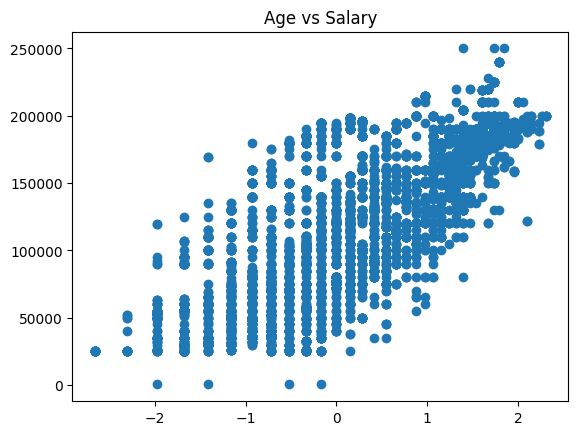

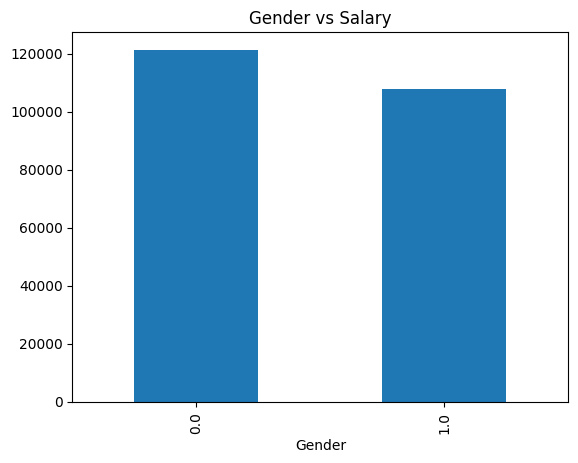

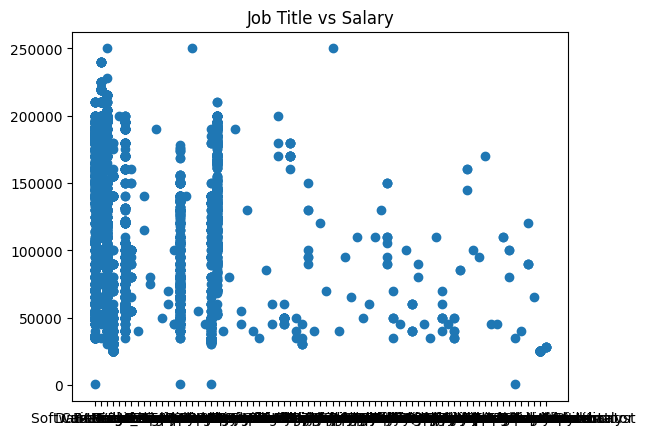

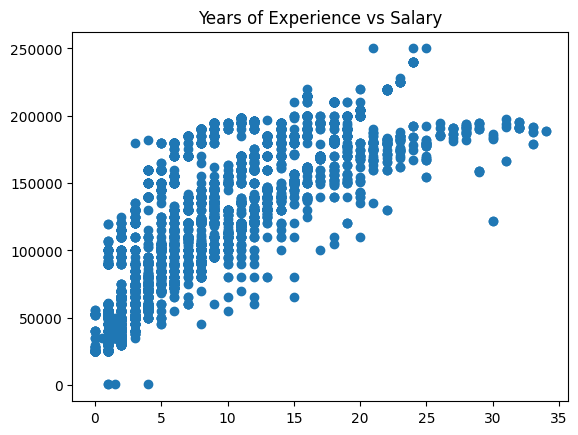

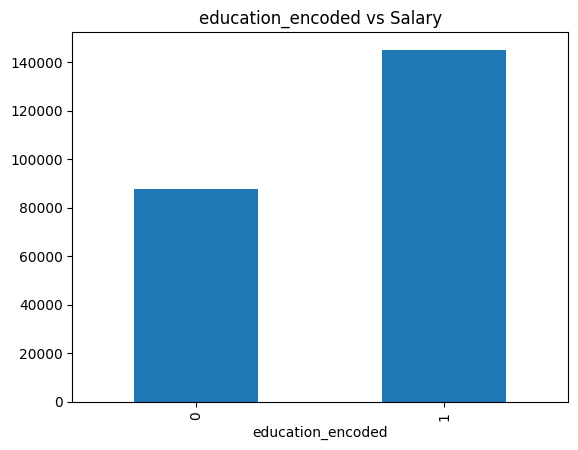

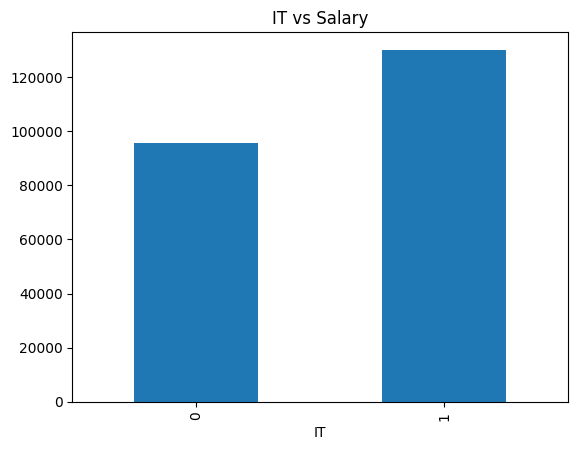

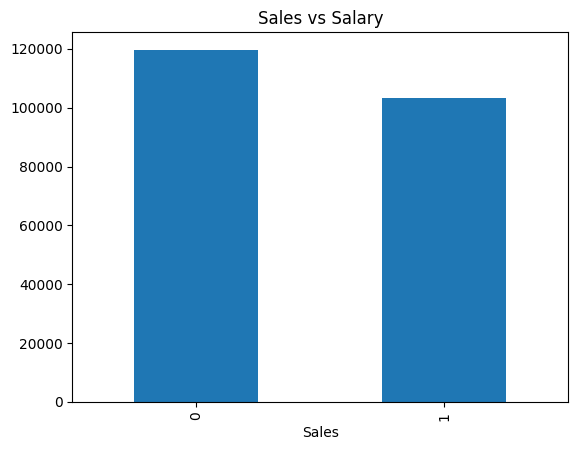

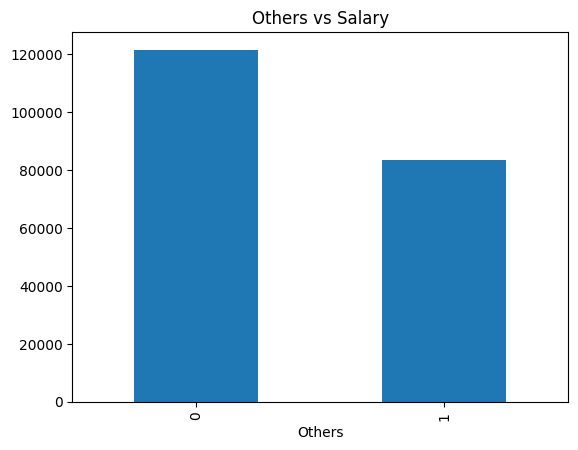

In [94]:
import matplotlib.pyplot as plt

for col in df.columns:
    if col != 'Salary':
        plt.figure()
        if df[col].nunique() <= 10:
            df.groupby(col)['Salary'].mean().plot(kind='bar')
        else:
            plt.scatter(df[col], df['Salary'])
        plt.title(f"{col} vs Salary")
        plt.show()

In [102]:
df = df.drop(columns='Job Title')

In [103]:
df

,Age,Gender,Years of Experience,Salary,education_encoded,IT,Sales,Others
0,-0.005862,0.0,5.0,90000.0,0,1,0,0
1,-0.717950,1.0,3.0,65000.0,1,1,0,0
2,1.396679,0.0,15.0,150000.0,1,0,1,0
3,0.540283,1.0,7.0,60000.0,0,0,1,0
4,1.846876,0.0,20.0,200000.0,1,0,0,1
...,...,...,...,...,...,...,...,...
6699,1.670727,1.0,20.0,200000.0,1,0,0,1
6700,-0.005862,0.0,3.0,50000.0,0,0,1,0
6701,-0.336900,1.0,4.0,55000.0,0,0,1,0
6702,1.469958,0.0,14.0,140000.0,1,0,1,0


In [108]:
df=df.dropna()

In [109]:
df.isnull().sum()

Age                    0
Gender                 0
Years of Experience    0
Salary                 0
education_encoded      0
IT                     0
Sales                  0
Others                 0
dtype: int64

In [111]:
df.shape

(6684, 8)

In [112]:
df['Gender'] = df['Gender'].astype(int)

C:\Users\ramit\AppData\Local\Temp\ipykernel_15180\2097908788.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df['Gender'].astype(int)


In [113]:
df

,Age,Gender,Years of Experience,Salary,education_encoded,IT,Sales,Others
0,-0.005862,0,5.0,90000.0,0,1,0,0
1,-0.717950,1,3.0,65000.0,1,1,0,0
2,1.396679,0,15.0,150000.0,1,0,1,0
3,0.540283,1,7.0,60000.0,0,0,1,0
4,1.846876,0,20.0,200000.0,1,0,0,1
...,...,...,...,...,...,...,...,...
6699,1.670727,1,20.0,200000.0,1,0,0,1
6700,-0.005862,0,3.0,50000.0,0,0,1,0
6701,-0.336900,1,4.0,55000.0,0,0,1,0
6702,1.469958,0,14.0,140000.0,1,0,1,0


In [114]:
df['Years of Experience'] = df['Years of Experience'].astype(int)

C:\Users\ramit\AppData\Local\Temp\ipykernel_15180\7117652.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Years of Experience'] = df['Years of Experience'].astype(int)


In [115]:
df

,Age,Gender,Years of Experience,Salary,education_encoded,IT,Sales,Others
0,-0.005862,0,5,90000.0,0,1,0,0
1,-0.717950,1,3,65000.0,1,1,0,0
2,1.396679,0,15,150000.0,1,0,1,0
3,0.540283,1,7,60000.0,0,0,1,0
4,1.846876,0,20,200000.0,1,0,0,1
...,...,...,...,...,...,...,...,...
6699,1.670727,1,20,200000.0,1,0,0,1
6700,-0.005862,0,3,50000.0,0,0,1,0
6701,-0.336900,1,4,55000.0,0,0,1,0
6702,1.469958,0,14,140000.0,1,0,1,0


<Axes: xlabel='Years of Experience', ylabel='Salary'>

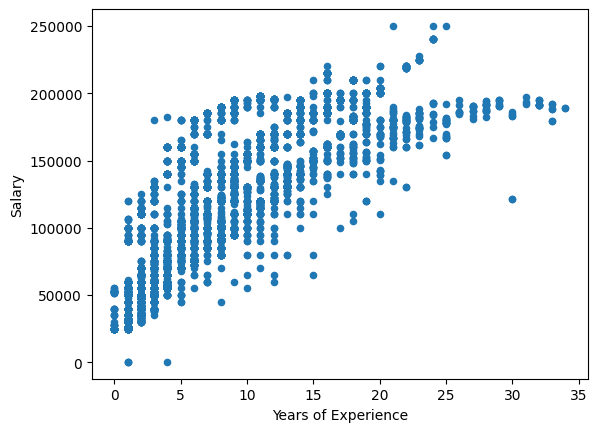

In [119]:
df.plot.scatter(x='Years of Experience', y='Salary')

In [121]:
df.plot.bar(x='Job', y='Salary')

KeyError: 'Job'

In [122]:
df

,Age,Gender,Years of Experience,Salary,education_encoded,IT,Sales,Others
0,-0.005862,0,5,90000.0,0,1,0,0
1,-0.717950,1,3,65000.0,1,1,0,0
2,1.396679,0,15,150000.0,1,0,1,0
3,0.540283,1,7,60000.0,0,0,1,0
4,1.846876,0,20,200000.0,1,0,0,1
...,...,...,...,...,...,...,...,...
6699,1.670727,1,20,200000.0,1,0,0,1
6700,-0.005862,0,3,50000.0,0,0,1,0
6701,-0.336900,1,4,55000.0,0,0,1,0
6702,1.469958,0,14,140000.0,1,0,1,0


<Axes: xlabel='Years of Experience'>

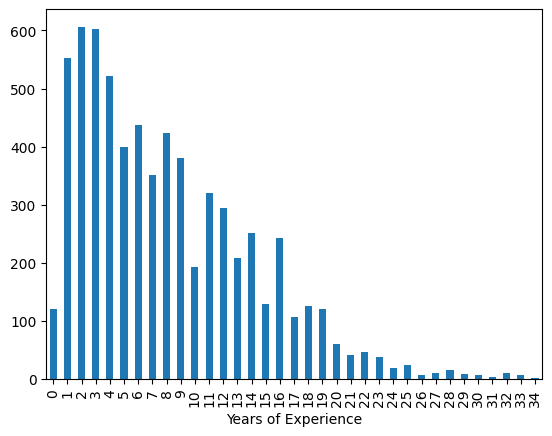

In [123]:
df['Years of Experience'].value_counts().sort_index().plot(kind='bar')

In [124]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df['Years of Experience'] = pt.fit_transform(df[['Years of Experience']])

C:\Users\ramit\AppData\Local\Temp\ipykernel_15180\3803519505.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Years of Experience'] = pt.fit_transform(df[['Years of Experience']])


In [125]:
df

,Age,Gender,Years of Experience,Salary,education_encoded,IT,Sales,Others
0,-0.005862,0,-0.318342,90000.0,0,1,0,0
1,-0.717950,1,-0.825512,65000.0,1,1,0,0
2,1.396679,0,1.139861,150000.0,1,0,1,0
3,0.540283,1,0.073488,60000.0,0,0,1,0
4,1.846876,0,1.610535,200000.0,1,0,0,1
...,...,...,...,...,...,...,...,...
6699,1.670727,1,1.610535,200000.0,1,0,0,1
6700,-0.005862,0,-0.825512,50000.0,0,0,1,0
6701,-0.336900,1,-0.552673,55000.0,0,0,1,0
6702,1.469958,0,1.032708,140000.0,1,0,1,0


In [141]:
X = df.drop(columns=['Salary'])
y = df['Salary']

In [142]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [143]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.9259851154965261


In [144]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kf)

print(scores)
print(scores.mean())

[0.92623547 0.92223356 0.93808069 0.93585752 0.93640381]
0.9317622115394075


In [146]:
df.to_csv("data.csv", index=False)

In [148]:
import joblib
joblib.dump(model, "salary_model.pkl")

['salary_model.pkl']

In [149]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))